Cell 1: Settings: Drive paths, repo and branch

In [1]:
# Google Drive locations
DRIVE_ROOT = "/content/drive/MyDrive/Documents/ACIT4030_Group_Assignment 2"   # results end up here
DATA_ZIP   = DRIVE_ROOT + "/data/acit4030-data.zip"                     # the zip from Canvas
PACKAGES   = "/content/drive/MyDrive/Colab_Packages"                    # PyTorch3D lives here

# GitHub
REPO_URL      = "github.com/SebastianHaugen/acit4030-NeRF.git"   # repo, without https://
BRANCH        = "jesse-branch"                           # the branch to train from
TOKEN_SECRET  = "token_github"                           # name of the secret in the Colab Secrets panel

REPO_DIR = "/content/acit4030-NeRF"

Cell 2: Check the runtime and GPU

In [2]:
import sys, torch

print(f"Python  {sys.version.split()[0]}")
print(f"PyTorch {torch.__version__}  (CUDA {torch.version.cuda})")
assert torch.cuda.is_available(), "No GPU - switch the runtime type to GPU"
print(f"GPU     {torch.cuda.get_device_name(0)}")

Python  3.13.15
PyTorch 2.11.0+cu128  (CUDA 12.8)
GPU     NVIDIA A100-SXM4-40GB


Cell 3: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Cell 4: Load PyTorch3D from Drive and check compatibility

In [4]:
import os
from pathlib import Path

os.makedirs(PACKAGES, exist_ok=True)
for p in (PACKAGES, PACKAGES + "/pytorch3d"):
    if p not in sys.path:
        sys.path.append(p)
os.environ["PYTHONPATH"] = PACKAGES + ":" + PACKAGES + "/pytorch3d"   # for !python subprocesses

runtime = f"Python {sys.version.split()[0]} | torch {torch.__version__} | CUDA {torch.version.cuda}"
build_file = Path(PACKAGES, "build_info.txt")
built_for = build_file.read_text().strip() if build_file.exists() else "unknown"
print("Runtime now: ", runtime)
print("Built for:   ", built_for)

try:
    from pytorch3d import _C   # the compiled part - fails if versions don't match
    import pytorch3d
    print(f"\nPyTorch3D {pytorch3d.__version__} works.")
except Exception as e:
    print(f"\nPyTorch3D not usable ({type(e).__name__}). Set INSTALL_PYTORCH3D = True below and run cell 5 once.")

Runtime now:  Python 3.13.15 | torch 2.11.0+cu128 | CUDA 12.8
Built for:    Python 3.13.15 | torch 2.11.0+cu128 | CUDA 12.8

PyTorch3D 0.7.8 works.


Cell 5: Install PyTorch3D to Drive (only if cell 4 fails, ~40 min, then restart)

In [ ]:
INSTALL_PYTORCH3D = False

if INSTALL_PYTORCH3D:
    !pip install 'git+https://github.com/facebookresearch/pytorch3d.git@stable' --target="{PACKAGES}" --upgrade
    build_file.write_text(runtime)
    print("Installed for", runtime, "- now restart the session.")
else:
    print("Skipped.")

Cell 6: Clone or update the repository

In [18]:
from google.colab import userdata

token = userdata.get(TOKEN_SECRET)
if not os.path.exists(REPO_DIR):
    !git clone -q https://{token}@{REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git fetch -q origin
!git checkout -q {BRANCH}
!git pull -q origin {BRANCH}
!git log -1 --format="On %D: %h %s"

/content/acit4030-NeRF
On HEAD -> jesse-branch, origin/jesse-branch: 80acc23 Update report_figures.py


Cell 7: Install Python packages from requirements.txt

In [6]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.4 MB/s eta 0:00:00


Cell 8: Unzip the dataset into data/

In [7]:
import shutil, subprocess

data_dir = Path(REPO_DIR, "data")

def dataset_ready():
    return (data_dir / "lego" / "transforms_train.json").exists() and \
           (data_dir / "poster" / "transforms.json").exists()

if not dataset_ready():
    tmp = Path("/content/_unzipped")
    shutil.rmtree(tmp, ignore_errors=True)
    subprocess.run(["unzip", "-q", DATA_ZIP, "-d", str(tmp)], check=True)
    data_dir.mkdir(exist_ok=True)
    for name in ("lego", "poster"):
        found = [p for p in tmp.rglob(name) if p.is_dir() and "__MACOSX" not in p.parts]
        assert found, f"No '{name}' folder in the zip"
        shutil.rmtree(data_dir / name, ignore_errors=True)
        shutil.move(str(found[0]), data_dir / name)
    shutil.rmtree(tmp)

print("Dataset ready:", dataset_ready())
for name in ("lego", "poster"):
    print(f"  {name}: {sorted(p.name for p in (data_dir / name).iterdir())}")

Dataset ready: True
  lego: ['test', 'train', 'transforms_test.json', 'transforms_train.json', 'transforms_val.json', 'val']
  poster: ['base_cam.json', 'colmap', 'images', 'images_2', 'images_4', 'images_8', 'sparse_pc.ply', 'transforms.json']


Cell 9: Link outputs/ to Google Drive

In [8]:
for name in ("lego", "poster"):
    target = Path(DRIVE_ROOT, "outputs", name)
    target.mkdir(parents=True, exist_ok=True)
    link = Path(REPO_DIR, "outputs", name)
    if link.is_symlink():
        continue
    if link.exists():            # a real folder from an earlier session: move its contents over
        for item in link.iterdir():
            shutil.move(str(item), target / item.name)
        link.rmdir()
    link.symlink_to(target)

!ls -l outputs

total 8
lrwxrwxrwx 1 root root 73 Sep 30 17:56 lego -> '/content/drive/MyDrive/Documents/ACIT4030_Group_Assignment 2/outputs/lego'
lrwxrwxrwx 1 root root 75 Sep 30 17:56 poster -> '/content/drive/MyDrive/Documents/ACIT4030_Group_Assignment 2/outputs/poster'


Cell 10: Define helpers: show(), show_last_preview()

In [9]:
from IPython.display import Image, display

def show(path, width=900):
    path = Path(REPO_DIR, path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print("Not found:", path)

def show_last_preview(run_dir, width=900):
    previews = sorted(Path(REPO_DIR, run_dir, "previews").glob("iter_*.png"))
    show(previews[-1], width) if previews else print("No previews in", run_dir)

!python -m src.repo_util.LoadConfigurations

Working successfully
Active dataset: lego
Data dir:       /content/acit4030-NeRF/data/lego
Output dir:     /content/acit4030-NeRF/outputs/lego
Iterations:     10000


Cell 11: Smoke test on lego (short run, checks that the loss goes down)

Smoke test on lego: 500 iterations -> /content/acit4030-NeRF/outputs/smoke_test/lego
Dataset: lego  (/content/acit4030-NeRF/data/lego)
Loading transforms_train.json
Using camera_angle_x: 0.691 rad, calculated FOV: 39.598 deg
Loading train split with 50 frames.
Loaded image dimensions: 800x800
Resizing images to: 200x200
Calculated Vertical FOV for camera: 39.598 degrees
50 training images at 200x200, 500 iterations
Decreasing LR by factor 0.1 ...

Done. Outputs in /content/acit4030-NeRF/outputs/smoke_test/lego

Loss: 0.2819 (start) -> 0.0886 (end), 69% lower
PASS: the model is learning. Safe to start the full run.


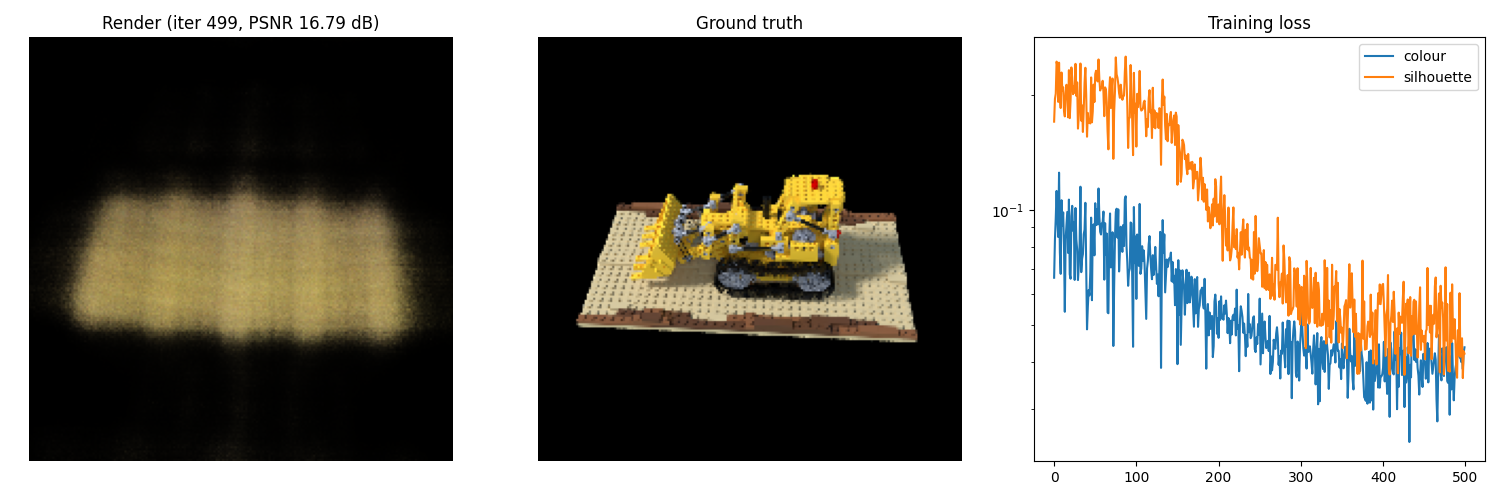

In [10]:
!NERF_DATASET=lego python -m src.smoke_test
show_last_preview("outputs/smoke_test/lego")

Cell 12: Train on lego (iterations from config.yaml)

Dataset: lego  (/content/acit4030-NeRF/data/lego)
Loading transforms_train.json
Using camera_angle_x: 0.691 rad, calculated FOV: 39.598 deg
Loading train split with 50 frames.
Loaded image dimensions: 800x800
Resizing images to: 200x200
Calculated Vertical FOV for camera: 39.598 degrees
50 training images at 200x200, 10000 iterations
Decreasing LR by factor 0.1 ...

Done. Outputs in /content/acit4030-NeRF/outputs/lego


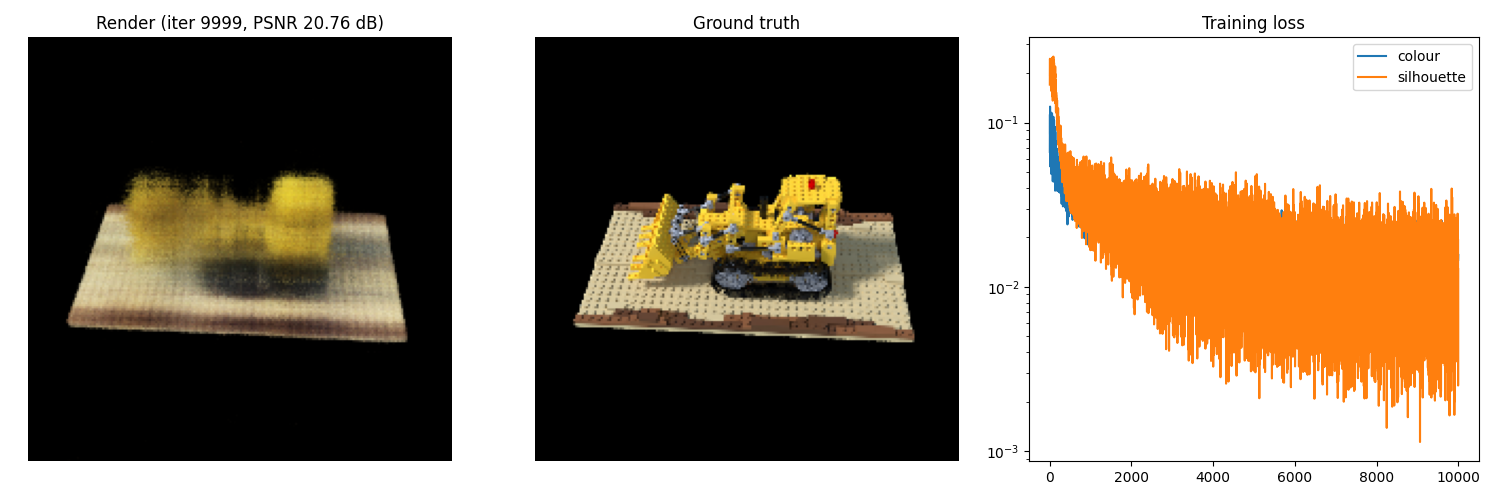

In [11]:
!NERF_DATASET=lego python -m src.train
show_last_preview("outputs/lego")

Cell 13: Evaluate lego on test views

Dataset: lego
Loading transforms_test.json
Using camera_angle_x: 0.691 rad, calculated FOV: 39.598 deg
Loading test split with 20 frames.
Loaded image dimensions: 800x800
Resizing images to: 200x200
Calculated Vertical FOV for camera: 39.598 degrees
Evaluating on 20 test views at 200x200
Loaded checkpoint from iteration 10000
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/a

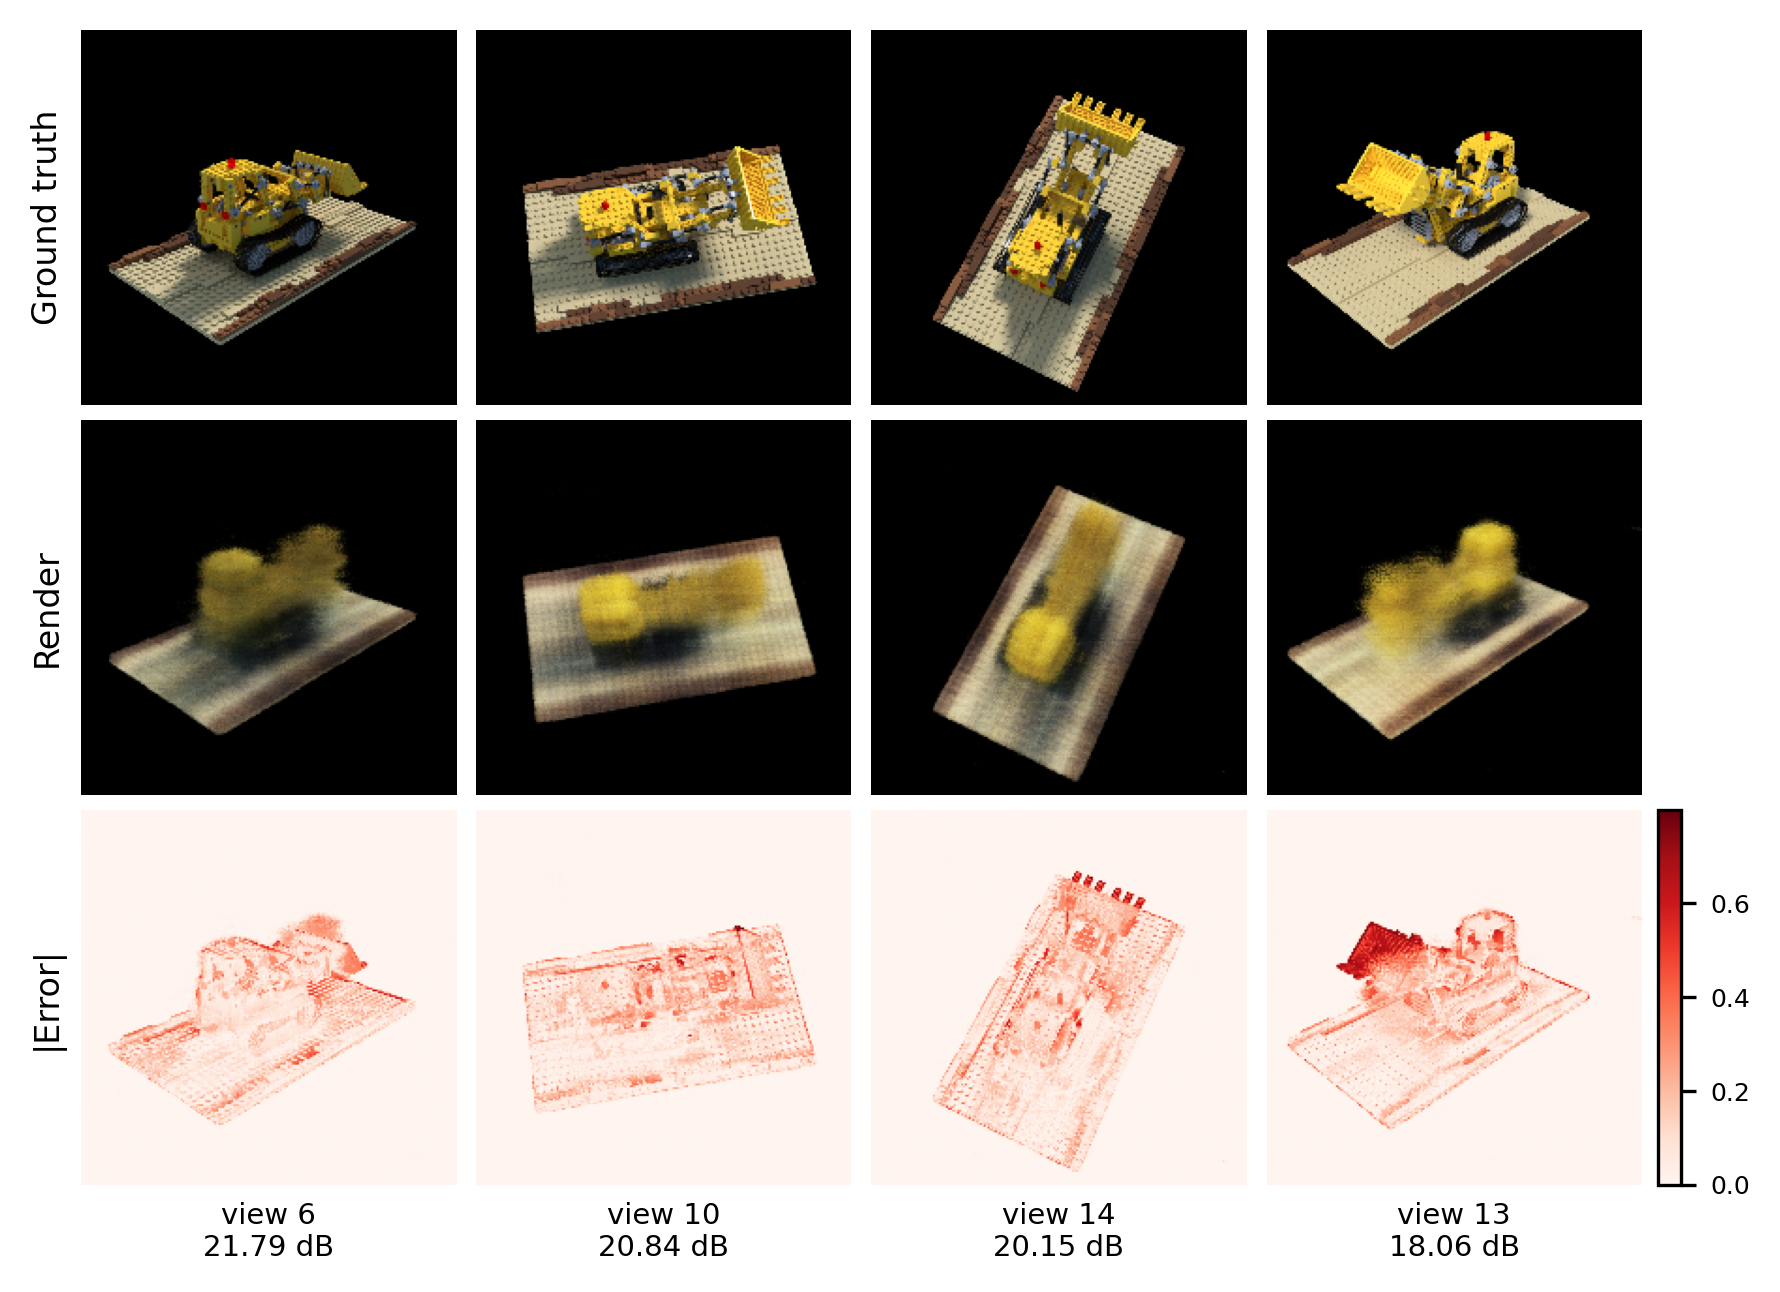

In [12]:
!NERF_DATASET=lego python -m src.evaluate
show("report/figures/qualitative_lego.png")

Cell 14: Smoke test on poster (short run, checks that the loss goes down)

Smoke test on poster: 500 iterations -> /content/acit4030-NeRF/outputs/smoke_test/poster
Dataset: poster  (/content/acit4030-NeRF/data/poster)
Using explicit intrinsics from transforms.json (scaled for 180x320):
  fl_x=191.19, fl_y=193.14, cx=90.00, cy=160.00
Loading train split with 226 frames.
Loaded image dimensions: 1080x1920
Resizing images to: 180x320
Calculated Vertical FOV for camera: 79.278 degrees
Found 'applied_transform' in transforms.json. Applying it to camera poses.
Held out every 8th image: 197 train images left.
197 training images at 180x320, 500 iterations
Decreasing LR by factor 0.1 ...

Done. Outputs in /content/acit4030-NeRF/outputs/smoke_test/poster

Loss: 0.3490 (start) -> 0.0895 (end), 74% lower
PASS: the model is learning. Safe to start the full run.


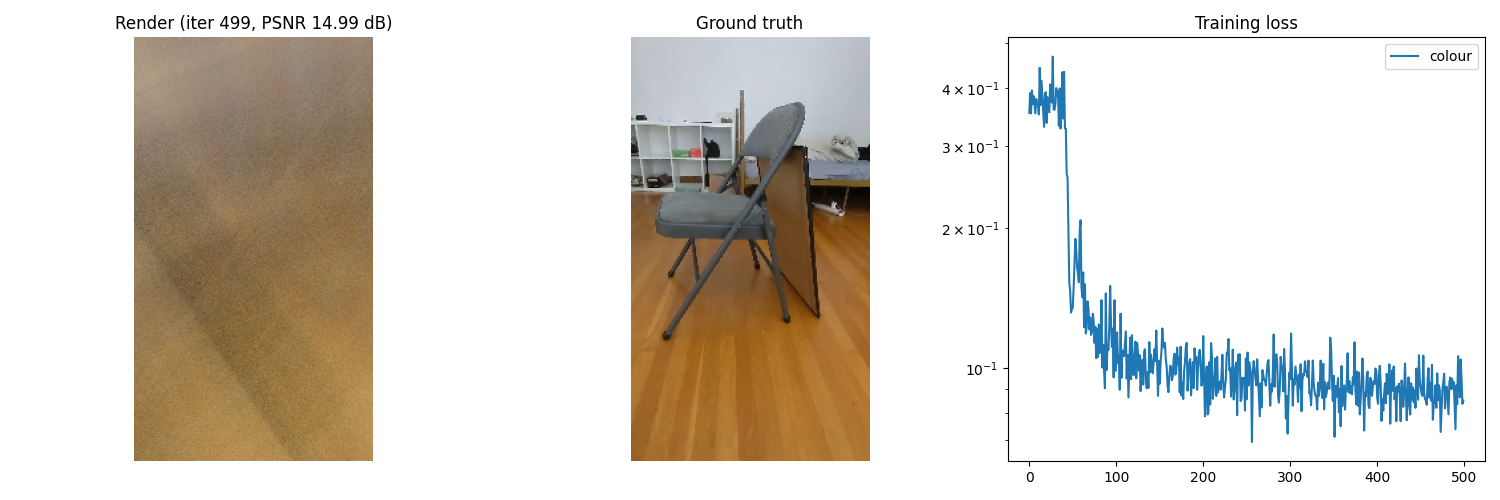

In [13]:
!NERF_DATASET=poster python -m src.smoke_test
show_last_preview("outputs/smoke_test/poster", width=600)

Cell 15: Train on poster (iterations from config.yaml)

Dataset: poster  (/content/acit4030-NeRF/data/poster)
Using explicit intrinsics from transforms.json (scaled for 180x320):
  fl_x=191.19, fl_y=193.14, cx=90.00, cy=160.00
Loading train split with 226 frames.
Loaded image dimensions: 1080x1920
Resizing images to: 180x320
Calculated Vertical FOV for camera: 79.278 degrees
Found 'applied_transform' in transforms.json. Applying it to camera poses.
Held out every 8th image: 197 train images left.
197 training images at 180x320, 60000 iterations
Decreasing LR by factor 0.1 ...

Done. Outputs in /content/acit4030-NeRF/outputs/poster


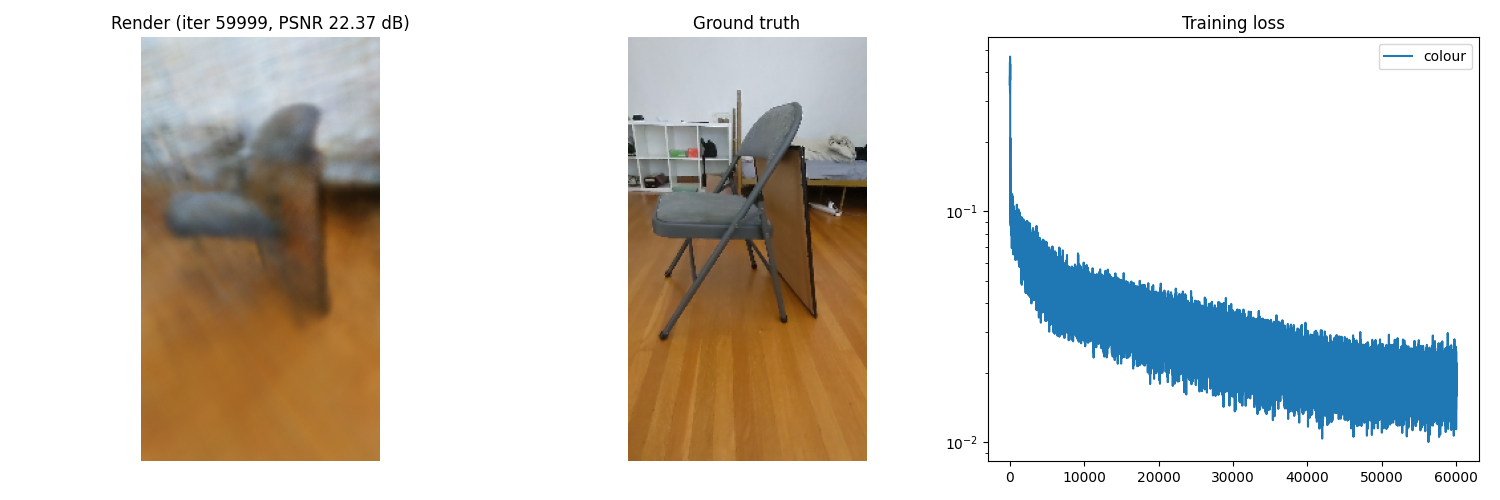

In [14]:
!NERF_DATASET=poster python -m src.train
show_last_preview("outputs/poster", width=600)

Cell 16: Evaluate poster on test views

Dataset: poster
Using explicit intrinsics from transforms.json (scaled for 180x320):
  fl_x=191.19, fl_y=193.14, cx=90.00, cy=160.00
Loading train split with 226 frames.
Loaded image dimensions: 1080x1920
Resizing images to: 180x320
Calculated Vertical FOV for camera: 79.278 degrees
Found 'applied_transform' in transforms.json. Applying it to camera poses.
Evaluating on 29 test views at 180x320
Loaded checkpoint from iteration 60000
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT`

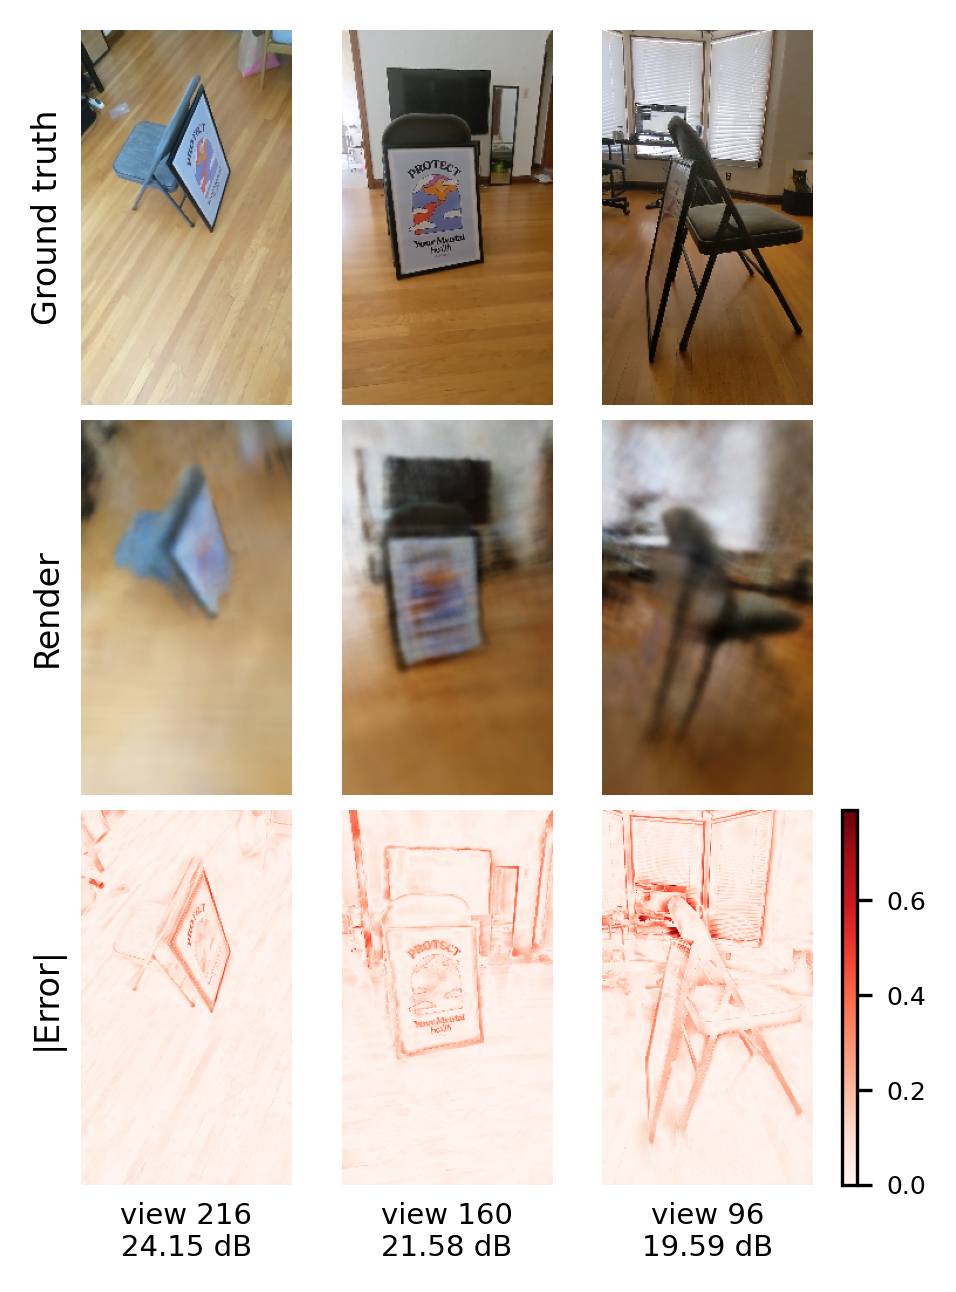

In [15]:
!NERF_DATASET=poster python -m src.evaluate
show("report/figures/qualitative_poster.png", width=450)

Cell 17: Build report figures and table, copy to Drive

In [20]:
!python -m src.report_figures
!cat report/figures/table_metrics.tex

figures_backup = Path(DRIVE_ROOT, "report_figures")
shutil.copytree(Path(REPO_DIR, "report", "figures"), figures_backup, dirs_exist_ok=True)
print("\nCopied to", figures_backup)
!ls "{figures_backup}"

Saved /content/acit4030-NeRF/report/figures/loss_curves.pdf
Saved /content/acit4030-NeRF/report/figures/table_metrics.tex
% Generated by src/report_figures.py - do not edit by hand, rerun the script.
% Needs \usepackage{booktabs} in the preamble. Include with \input{figures/table_metrics.tex}
\begin{table}[t]
\centering
\caption{Quantitative results on the held-out test views (mean $\pm$ standard deviation).}
\label{tab:metrics}
\begin{tabular}{lcccc}
\toprule
Dataset & Views & PSNR $\uparrow$ (dB) & SSIM $\uparrow$ & LPIPS $\downarrow$ \\
\midrule
Lego & 20 & $20.41 \pm 0.87$ & $0.799 \pm 0.015$ & $0.259 \pm 0.032$ \\
Poster & 29 & $21.67 \pm 1.09$ & $0.656 \pm 0.038$ & $0.560 \pm 0.053$ \\
% Optional reference row, values from the original NeRF paper:
% Lego (original NeRF) & -- & ... & ... & ... \\
\bottomrule
\end{tabular}
\end{table}

Copied to /content/drive/MyDrive/Documents/ACIT4030_Group_Assignment 2/report_figures
loss_curves.pdf       qualitative_poster.png  table_metrics.te

Cell 18: Check that no tracked file was changed (config.yaml stays as committed)

In [17]:
!git status --short

?? report/figures/loss_curves.pdf
?? report/figures/qualitative_lego.png
?? report/figures/qualitative_poster.png
?? report/figures/table_metrics.tex
